# Hospital Operations Intelligence Platform

## Notebook 01: Data Cleaning Pipeline

### Business objective

Hospital data arrives from multiple operational systems and cannot be trusted
until quality rules are applied consistently. This notebook converts the raw
admissions and claims extracts into clean, analysis-ready datasets.

### Pipeline

1. Load and profile raw files
2. Validate keys, dates, categories, and billing rules
3. Treat missing values
4. Remove duplicate keys
5. Correct data types
6. Winsorize numerical outliers
7. Preserve a documented surrogate claim linkage
8. Save clean datasets and quality reports

## 1. Imports and project paths

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
for folder in [PROCESSED, MODELS, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_pipeline import (
    clean_admissions,
    clean_billing,
    link_billing_to_admissions,
    validate_raw,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


## 2. Load raw data

In [2]:
admissions_raw = pd.read_csv(RAW / "admissions.csv")
claims_raw = pd.read_csv(RAW / "claims_and_billing.csv")

print("Admissions:", admissions_raw.shape)
print("Claims and billing:", claims_raw.shape)
display(admissions_raw.head())
display(claims_raw.head())

Admissions: (120000, 17)
Claims and billing: (70000, 10)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,06-02-2025 00:00,1971.52,0.00,Denied
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,01-05-2025 00:00,1243.80,736.05,Paid
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,23-02-2025 00:00,4854.11,2676.12,Paid
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,20-04-2025 00:00,2638.21,1861.39,Paid
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaN,1046.99,1046.99,Paid


## 3. Data overview and validation

In [3]:
overview = pd.DataFrame(
    {
        "dataset": ["admissions", "claims"],
        "rows": [len(admissions_raw), len(claims_raw)],
        "columns": [admissions_raw.shape[1], claims_raw.shape[1]],
        "duplicate_rows": [
            admissions_raw.duplicated().sum(),
            claims_raw.duplicated().sum(),
        ],
        "missing_cells": [
            admissions_raw.isna().sum().sum(),
            claims_raw.isna().sum().sum(),
        ],
    }
)
display(overview)
display(admissions_raw.describe(include="all").T)
display(claims_raw.describe(include="all").T)

,dataset,rows,columns,duplicate_rows,missing_cells
0,admissions,120000,17,0,0
1,claims,70000,10,0,20724


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
admission_id,120000,120000,bcb311d6-0808-498f-8ae1-11abe1fbc08e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,120000,64873,dd0ca7f5-a2e4-4077-8602-49690edaca7e,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admit_date,120000,3652,2019-07-06,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_date,120000,3677,2020-07-01,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
los_days,120000.0,NaN,NaN,NaN,6.852708,5.708269,1.0,3.0,5.0,9.0,90.0
admit_type,120000,3,Emergency,66540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ward_type,120000,4,General,76768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_id,120000,33,a86650ea-3517-4285-bc11-ffa2085a8df2,3736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_type,120000,4,Recovered,87420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_procedures,120000.0,NaN,NaN,NaN,1.523742,1.542197,0.0,0.0,1.0,2.0,15.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
billing_id,70000,70000,BILL000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,70000,60000,PAT052502,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
encounter_id,70000,70000,ENC000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,70000,7,Medicaid,10108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,70000,2,Insurance,59638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim_id,59638,59638,CLM000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim_billing_date,59638,115,22-03-2025 00:00,728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billed_amount,70000.0,NaN,NaN,NaN,1612.866283,2047.355083,100.07,697.0475,1214.11,2090.125,38191.35
paid_amount,70000.0,NaN,NaN,NaN,1040.652151,1478.713641,0.0,366.5725,755.785,1357.895,38191.35
claim_status,70000,2,Paid,64002,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
validation_rules = pd.DataFrame(
    {
        "rule": [
            "Unique admission_id",
            "Unique billing_id",
            "Discharge date is not before admission",
            "Paid amount does not exceed billed amount",
            "Known claim status",
        ],
        "failures": [
            admissions_raw.duplicated("admission_id").sum(),
            claims_raw.duplicated("billing_id").sum(),
            (
                pd.to_datetime(admissions_raw["discharge_date"], errors="coerce")
                < pd.to_datetime(admissions_raw["admit_date"], errors="coerce")
            ).sum(),
            (
                pd.to_numeric(claims_raw["paid_amount"], errors="coerce")
                > pd.to_numeric(claims_raw["billed_amount"], errors="coerce")
            ).sum(),
            (~claims_raw["claim_status"].isin(["Paid", "Denied", "Pending"])).sum(),
        ],
    }
)
display(validation_rules)
validate_raw(admissions_raw, claims_raw)
print("Excel validation workbook refreshed.")

,rule,failures
0,Unique admission_id,0
1,Unique billing_id,0
2,Discharge date is not before admission,0
3,Paid amount does not exceed billed amount,0
4,Known claim status,0


Excel validation workbook refreshed.


### Missing-value strategy

- Numeric clinical values: median imputation
- Operational categories: `Unknown`
- Invalid dates: coercion to missing, then governed review
- Duplicate business keys: retain the first valid record
- Extreme numeric values: IQR winsorization, preserving patient rows

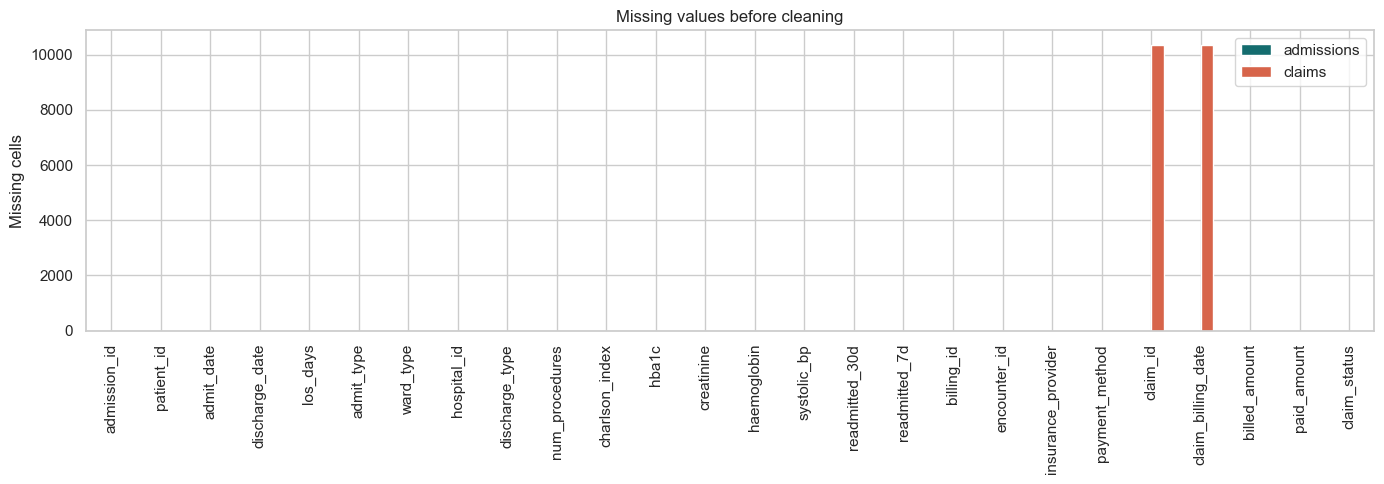

In [4]:
missing = pd.concat(
    [
        admissions_raw.isna().sum().rename("admissions"),
        claims_raw.isna().sum().rename("claims"),
    ],
    axis=1,
).fillna(0)

ax = missing.plot(kind="bar", figsize=(14, 5), color=["#146C6E", "#D7644A"])
ax.set_title("Missing values before cleaning")
ax.set_ylabel("Missing cells")
plt.tight_layout()
plt.show()

## 4. Clean, type-correct, and link data

In [5]:
admissions_clean = clean_admissions(admissions_raw)
claims_clean = clean_billing(claims_raw)
claims_clean = link_billing_to_admissions(claims_clean, admissions_clean)

quality_comparison = pd.DataFrame(
    {
        "dataset": ["admissions", "claims"],
        "raw_rows": [len(admissions_raw), len(claims_raw)],
        "clean_rows": [len(admissions_clean), len(claims_clean)],
        "raw_missing": [
            admissions_raw.isna().sum().sum(),
            claims_raw.isna().sum().sum(),
        ],
        "clean_missing": [
            admissions_clean.isna().sum().sum(),
            claims_clean.isna().sum().sum(),
        ],
        "duplicate_keys_after": [
            admissions_clean.duplicated("admission_id").sum(),
            claims_clean.duplicated("billing_id").sum(),
        ],
    }
)
display(quality_comparison)
display(admissions_clean.dtypes.to_frame("dtype"))

,dataset,raw_rows,clean_rows,raw_missing,clean_missing,duplicate_keys_after
0,admissions,120000,120000,0,0,0
1,claims,70000,70000,20724,10362,0


,dtype
admission_id,str
patient_id,str
admit_date,datetime64[us]
discharge_date,datetime64[us]
los_days,int64
admit_type,str
ward_type,str
hospital_id,str
discharge_type,str
num_procedures,int64


The source files have no overlapping patient or encounter identifiers.
`link_billing_to_admissions` therefore creates a reproducible surrogate link,
retains both original identifiers, and records the linkage method. The derived
join is suitable for demonstrating architecture, not clinical attribution.

## 5. Outlier assessment

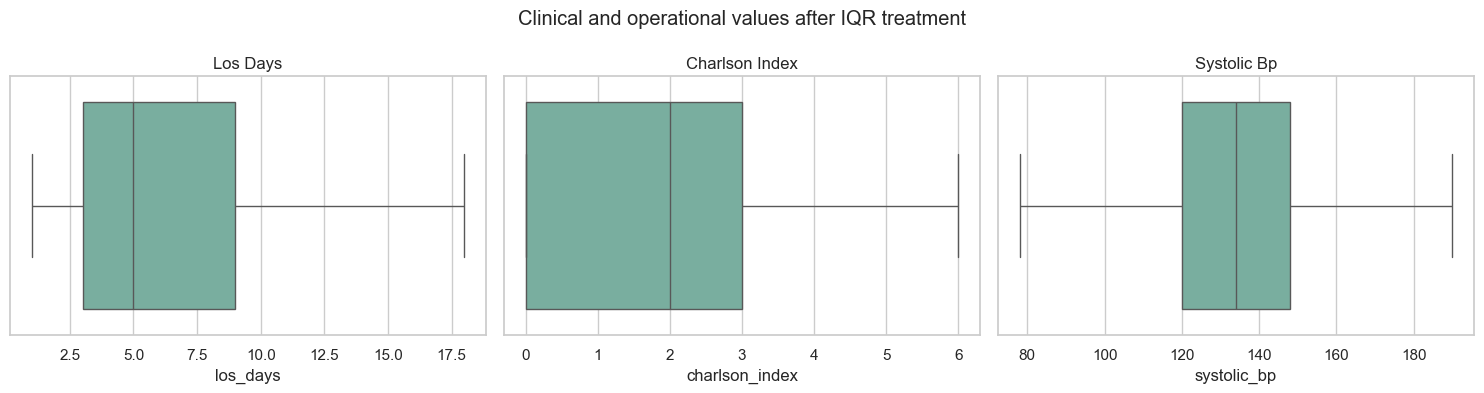

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(
    axes, ["los_days", "charlson_index", "systolic_bp"]
):
    sns.boxplot(data=admissions_clean, x=column, ax=axis, color="#70B7A3")
    axis.set_title(column.replace("_", " ").title())
plt.suptitle("Clinical and operational values after IQR treatment")
plt.tight_layout()
plt.show()

## 6. Save clean outputs

In [7]:
admissions_clean.to_csv(PROCESSED / "admissions_clean.csv", index=False)
claims_clean.to_csv(PROCESSED / "billing_clean.csv", index=False)

# Portfolio-friendly aliases requested by the notebook workflow.
admissions_clean.to_csv(ROOT / "datasets" / "clean_admissions.csv", index=False)
claims_clean.to_csv(ROOT / "datasets" / "clean_claims.csv", index=False)

quality_comparison.to_csv(REPORTS / "cleaning_quality_summary.csv", index=False)
print("Saved:")
print("-", ROOT / "datasets" / "clean_admissions.csv")
print("-", ROOT / "datasets" / "clean_claims.csv")
print("-", REPORTS / "cleaning_quality_summary.csv")

Saved:
- c:\Users\HP\Desktop\Hospital OP Inteligent sys\datasets\clean_admissions.csv
- c:\Users\HP\Desktop\Hospital OP Inteligent sys\datasets\clean_claims.csv
- c:\Users\HP\Desktop\Hospital OP Inteligent sys\reports\cleaning_quality_summary.csv


## Business conclusions

- Business keys are unique after cleaning.
- Dates and numeric fields use consistent analytical types.
- Missing values are handled with documented domain rules.
- Outliers are controlled without deleting patient encounters.
- Claims remain traceable to their original source identifiers.

The outputs are ready for exploratory analysis, but all surrogate relationships
must be replaced by governed source-system keys before real hospital use.